# Chapter 4 — Two-Stage Training

*Build a Multimodal Model from Scratch*

---

We have a pretrained ViT that understands images and a pretrained GPT that understands text.
The challenge: **how do we connect them without destroying what each already knows?**

This chapter solves three concrete problems, each building on the last:

| # | Problem | Solution |
|---|---------|----------|
| 1 | Training everything at once destroys pretrained features | Two-stage protocol |
| 2 | How do we teach the bridge (ProjectionMLP) without touching the experts? | Freeze ViT+GPT, train projector only (Stage 1) |
| 3 | How do we fine-tune the whole system safely? | Unfreeze GPT with cosine LR decay (Stage 2) |


In [1]:
%matplotlib inline
import os, math, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use all available CPU threads for faster matrix ops
torch.set_num_threads(os.cpu_count() or 4)

os.makedirs("figures", exist_ok=True)
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9', orange='#E67E22', green='#27AE60', red='#E74C3C', purple='#8E44AD', grey='#95A5A6')
print(f"Device: {DEVICE}  |  CPU threads: {torch.get_num_threads()}")


Device: cpu  |  CPU threads: 4


## Problem 1 — Training Everything at Once Breaks Things

Suppose we have:
- A **ViT** pretrained on millions of images (encodes edges, textures, objects)
- A **GPT** pretrained on billions of text tokens (encodes grammar, semantics, world knowledge)
- A freshly-initialised **ProjectionMLP** connecting them

If we train all three jointly from scratch, here is what goes wrong:

1. **Random projections produce garbage visual tokens.** The GPT sees random-looking vectors where it expects meaningful embeddings. Every attention layer fires incorrectly.
2. **GPT gradients try to compensate.** The language model's weights shift to accommodate the noise, overwriting its learned text representations — *catastrophic forgetting*.
3. **Training becomes unstable.** The projection chases a moving target (GPT changing) while GPT chases another (projection changing).

**Analogy:** You hire a translator to bridge two experts. You would not force the experts to re-learn their fields while the translator is still in week one.

**Solution:** Two stages — first teach the translator alone, then let the second expert fine-tune together.


### Visualising the Two Stages

Which components are **frozen** (grey) versus **actively training** (coloured) in each stage.


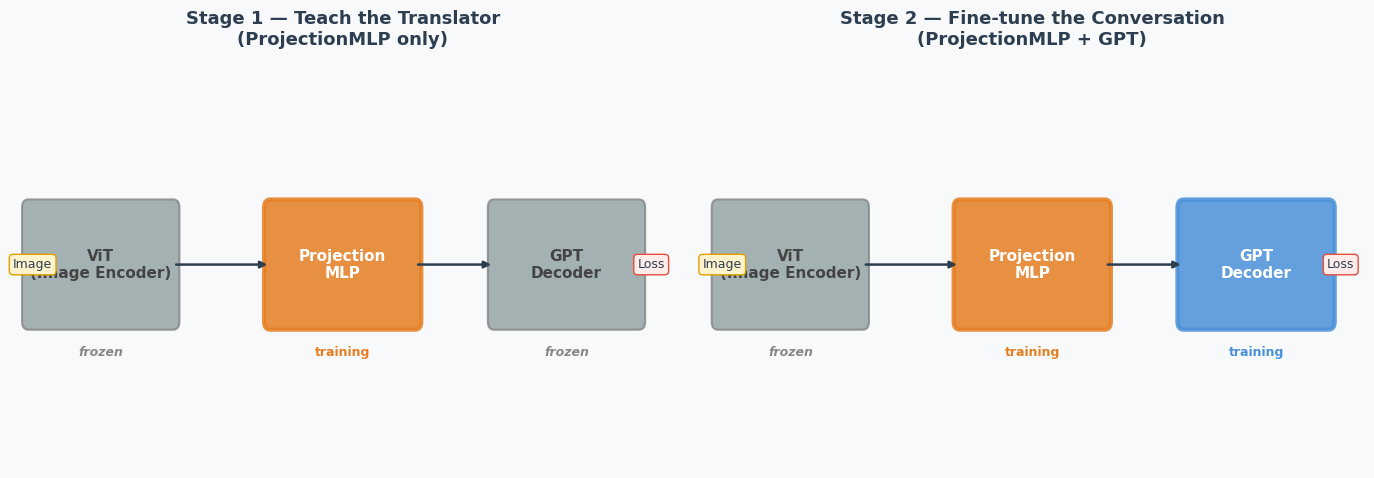

Saved: figures/two_stage_overview.png


In [2]:
def draw_two_stage_overview():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(PAL["bg"])

    def draw_stage(ax, title, states):
        ax.set_facecolor(PAL["bg"])
        ax.set_xlim(0, 11); ax.set_ylim(0, 5); ax.axis("off")
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12, color=PAL["dark"])
        boxes = [
            (0.3, 1.8, 2.4, 1.4, "ViT\n(Image Encoder)", "vit"),
            (4.3, 1.8, 2.4, 1.4, "Projection\nMLP", "proj"),
            (8.0, 1.8, 2.4, 1.4, "GPT\nDecoder", "gpt"),
        ]
        for (x, y, w, h, label, key) in boxes:
            mode, col = states[key]
            frozen = (mode == "frozen")
            face = PAL["grey"] if frozen else col
            edge = "#888888" if frozen else col
            rect = mpatches.FancyBboxPatch(
                (x, y), w, h, boxstyle="round,pad=0.1",
                facecolor=face, edgecolor=edge,
                linewidth=1.5 if frozen else 3.0, alpha=0.85)
            ax.add_patch(rect)
            ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                    fontsize=11, color="white" if not frozen else "#444",
                    fontweight="bold")
            badge = "frozen" if frozen else "training"
            badge_col = "#888" if frozen else col
            ax.text(x + w/2, y - 0.3, badge, ha="center", va="top",
                    fontsize=9, color=badge_col,
                    style="italic" if frozen else "normal", fontweight="bold")
        for x1, x2 in [(2.7, 4.3), (6.7, 8.0)]:
            ax.annotate("", xy=(x2, 2.5), xytext=(x1, 2.5),
                        arrowprops=dict(arrowstyle="-|>", color=PAL["dark"], lw=1.8))
        ax.text(0.05, 2.5, "Image", ha="left", va="center", fontsize=9,
                color=PAL["dark"],
                bbox=dict(boxstyle="round,pad=0.3", fc="#FFF3CD", ec="#E0A000"))
        ax.text(10.6, 2.5, "Loss", ha="center", va="center", fontsize=9,
                color=PAL["dark"],
                bbox=dict(boxstyle="round,pad=0.3", fc="#FDECEA", ec=PAL["red"]))

    draw_stage(axes[0], "Stage 1 — Teach the Translator\n(ProjectionMLP only)", {
        "vit":  ("frozen", PAL["grey"]),
        "proj": ("active", PAL["orange"]),
        "gpt":  ("frozen", PAL["grey"]),
    })
    draw_stage(axes[1], "Stage 2 — Fine-tune the Conversation\n(ProjectionMLP + GPT)", {
        "vit":  ("frozen", PAL["grey"]),
        "proj": ("active", PAL["orange"]),
        "gpt":  ("active", PAL["blue"]),
    })
    plt.tight_layout(pad=1.5)
    plt.savefig("figures/two_stage_overview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: figures/two_stage_overview.png")

draw_two_stage_overview()


### Which Parameters Are Trainable in Each Stage?

Before writing a single line of training code, lock in the rule visually.


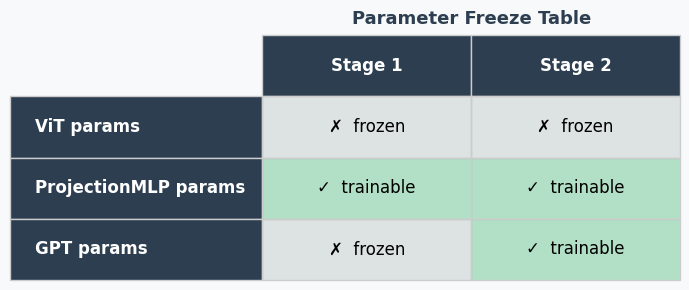

In [3]:
def show_parameter_freeze():
    fig, ax = plt.subplots(figsize=(7, 3.0))
    fig.patch.set_facecolor(PAL["bg"])
    ax.set_facecolor(PAL["bg"]); ax.axis("off")
    ax.set_title("Parameter Freeze Table", fontsize=13, fontweight="bold",
                 color=PAL["dark"], pad=8)
    rows = ["ViT params", "ProjectionMLP params", "GPT params"]
    cols = ["Stage 1", "Stage 2"]
    data = [[False, False], [True, True], [False, True]]
    cell_text   = []
    cell_colors = []
    for row_data in data:
        rt, rc = [], []
        for trainable in row_data:
            rt.append("✓  trainable" if trainable else "✗  frozen")
            rc.append(PAL["green"] + "55" if trainable else PAL["grey"] + "44")
        cell_text.append(rt); cell_colors.append(rc)
    table = ax.table(cellText=cell_text, cellColours=cell_colors,
                     rowLabels=rows, colLabels=cols,
                     cellLoc="center", loc="center", bbox=[0.0, 0.0, 1.0, 1.0])
    table.auto_set_font_size(False); table.set_fontsize(12)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#CCCCCC")
        if r == 0 or c == -1:
            cell.set_facecolor(PAL["dark"])
            cell.set_text_props(color="white", fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/parameter_freeze_table.png", dpi=120, bbox_inches="tight")
    plt.show()

show_parameter_freeze()


## Problem 2 — Stage 1: Teaching the Translator (ProjectionMLP Only)

Now we build all components. This notebook is **self-contained** — every class is redefined here.

### Model architecture (small dims for fast CPU training)

| Component | embed_dim | depth | n_heads |
|-----------|-----------|-------|---------|
| ViTEncoder | 32 | 1 | 2 |
| ProjectionMLP | 32→64 | 2 layers | — |
| GPTDecoder | 64 | 1 | 2 |

These are intentionally minimal. Real VLMs (LLaVA, InstructBLIP) use ViT-L/14 (embed_dim=1024) and 7B+ LLMs — the same two-stage protocol with larger numbers.


In [4]:
# ── ViT components (self-contained) ──────────────────────────────────────────

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3, embed_dim=32):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):                                  # (B, C, H, W)
        return self.proj(x).flatten(2).transpose(1, 2)    # (B, N, D)


class PositionalEmbedding(nn.Module):
    def __init__(self, n_tokens, embed_dim):
        super().__init__()
        self.emb = nn.Parameter(torch.zeros(1, n_tokens, embed_dim))
        nn.init.trunc_normal_(self.emb, std=0.02)

    def forward(self, x):
        return x + self.emb


class MultiHeadSelfAttention(nn.Module):
    """Wraps nn.MultiheadAttention; supports optional causal mask + visual prefix."""
    def __init__(self, embed_dim, n_heads, causal=False):
        super().__init__()
        self.attn   = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.causal = causal

    def forward(self, x, n_visual=0):
        T = x.shape[1]
        mask = None
        if self.causal:
            mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
            if n_visual > 0:
                mask[:n_visual, :] = False       # visual tokens: attend to everything
                mask[n_visual:, :n_visual] = False  # text tokens: see all visual tokens
        out, _ = self.attn(x, x, x, attn_mask=mask)
        return out


class ViTBlock(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, n_heads, causal=False)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4), nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ffn(self.norm2(x))


class ViTEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3,
                 embed_dim=32, depth=1, n_heads=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, embed_dim)
        n = self.patch_embed.n_patches
        self.cls    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos    = PositionalEmbedding(n + 1, embed_dim)
        self.blocks = nn.ModuleList([ViTBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm   = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        t = self.patch_embed(x)
        t = torch.cat([self.cls.expand(B, -1, -1), t], dim=1)
        t = self.pos(t)
        for blk in self.blocks:
            t = blk(t)
        return self.norm(t)[:, 1:, :]   # patch tokens only, (B, N, D)

print("ViTEncoder  ✓")


ViTEncoder  ✓


In [5]:
# ── GPT Decoder (self-contained) ─────────────────────────────────────────────

class GPTBlock(nn.Module):
    """Causal attention block; visual prefix positions attend bidirectionally."""
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, n_heads, causal=True)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4), nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim))

    def forward(self, x, n_visual=0):
        x = x + self.attn(self.norm1(x), n_visual=n_visual)
        return x + self.ffn(self.norm2(x))


class GPTDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, depth=1, n_heads=2, max_seq=64):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_seq, embed_dim)
        self.blocks  = nn.ModuleList([GPTBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm    = nn.LayerNorm(embed_dim)
        self.head    = nn.Linear(embed_dim, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight   # weight tying
        self.max_seq = max_seq

    def forward(self, input_ids, visual_prefix=None):
        B, T  = input_ids.shape
        dev   = input_ids.device
        tok   = self.tok_emb(input_ids)
        n_vis = 0
        if visual_prefix is not None:
            n_vis = visual_prefix.shape[1]
            vpos  = self.pos_emb(torch.arange(n_vis, device=dev)).unsqueeze(0)
            tpos  = self.pos_emb(torch.arange(n_vis, n_vis + T, device=dev)).unsqueeze(0)
            x = torch.cat([visual_prefix + vpos, tok + tpos], dim=1)
        else:
            pos = self.pos_emb(torch.arange(T, device=dev)).unsqueeze(0)
            x   = tok + pos
        for blk in self.blocks:
            x = blk(x, n_visual=n_vis)
        return self.norm(x), n_vis   # (B, n_vis+T, D) and n_vis

print("GPTDecoder  ✓")


GPTDecoder  ✓


In [6]:
# ── ProjectionMLP — the two-layer GELU bridge ─────────────────────────────────

class ProjectionMLP(nn.Module):
    """Maps visual tokens from ViT space (vision_dim) into GPT space (lang_dim).

    Why two layers + GELU?
    A single linear layer can only rescale/rotate axes.
    The hidden GELU lets the projection learn non-linear rearrangements needed
    to bridge the different statistical structures of image vs. text embeddings.
    """
    def __init__(self, vision_dim, lang_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vision_dim, lang_dim), nn.GELU(),
            nn.Linear(lang_dim, lang_dim),
        )

    def forward(self, x):   # (B, N_patches, vision_dim) → (B, N_patches, lang_dim)
        return self.net(x)


# ── VisionLanguageModel ────────────────────────────────────────────────────────

class VisionLanguageModel(nn.Module):
    def __init__(self, vit, proj, gpt):
        super().__init__()
        self.vit  = vit
        self.proj = proj
        self.gpt  = gpt

    def forward(self, images, input_ids, labels=None):
        patches       = self.vit(images)              # (B, N_img, vision_dim)
        visual_prefix = self.proj(patches)             # (B, N_img, lang_dim)
        hidden, n_vis = self.gpt(input_ids, visual_prefix)
        logits        = self.gpt.head(hidden)          # (B, n_vis+T, vocab)
        loss = None
        if labels is not None:
            text_logits  = logits[:, n_vis:-1, :]     # predict next text token
            text_targets = labels[:, 1:]               # shifted targets
            loss = F.cross_entropy(
                text_logits.reshape(-1, text_logits.size(-1)),
                text_targets.reshape(-1),
                ignore_index=-100,
            )
        return logits, loss

    # ── Stage control ──────────────────────────────────────────────────────────

    def set_stage1(self):
        """Freeze ViT and GPT; train only ProjectionMLP."""
        for p in self.vit.parameters():  p.requires_grad_(False)
        for p in self.gpt.parameters():  p.requires_grad_(False)
        for p in self.proj.parameters(): p.requires_grad_(True)
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Stage 1 active: {trainable:,} / {total:,} params  ({100*trainable/total:.1f}%)")

    def set_stage2(self):
        """Keep ViT frozen; unfreeze GPT and ProjectionMLP."""
        for p in self.vit.parameters():  p.requires_grad_(False)
        for p in self.proj.parameters(): p.requires_grad_(True)
        for p in self.gpt.parameters():  p.requires_grad_(True)
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Stage 2 active: {trainable:,} / {total:,} params  ({100*trainable/total:.1f}%)")

print("ProjectionMLP + VisionLanguageModel  ✓")


ProjectionMLP + VisionLanguageModel  ✓


### Synthetic Dataset: 4 Image Classes

We need (image, caption) pairs. The synthetic dataset is simple enough for genuine learning — loss curves will show real convergence.

| Class | Image | Caption |
|-------|-------|---------|
| 0 | Solid red | `"a solid red image"` |
| 1 | Solid blue | `"a solid blue image"` |
| 2 | Red/blue vertical stripes | `"an image with vertical stripes"` |
| 3 | Red/blue horizontal stripes | `"an image with horizontal stripes"` |

The `CharTokenizer` maps each character to an integer. Labels mask the `<SOS>` token with `-100` — `F.cross_entropy(ignore_index=-100)` skips those positions automatically.


In [7]:
class CharTokenizer:
    """Character-level tokenizer with <PAD>, <SOS>, <EOS> special tokens."""
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.vocab = ["<PAD>", "<SOS>", "<EOS>"] + chars
        self.stoi  = {c: i for i, c in enumerate(self.vocab)}
        self.itos  = {i: c for i, c in enumerate(self.vocab)}
        self.PAD, self.SOS, self.EOS = 0, 1, 2

    @property
    def vocab_size(self): return len(self.vocab)

    def encode(self, text, max_len=32, add_special=True):
        ids = [self.stoi[c] for c in text if c in self.stoi]
        if add_special:
            ids = [self.SOS] + ids + [self.EOS]
        ids = ids[:max_len]
        ids += [self.PAD] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        out = []
        for i in ids:
            tok = self.itos.get(i, "")
            if tok in ("<PAD>", "<SOS>"): continue
            if tok == "<EOS>": break
            out.append(tok)
        return "".join(out)


CAPTIONS = [
    "a solid red image",
    "a solid blue image",
    "an image with vertical stripes",
    "an image with horizontal stripes",
]
tokenizer = CharTokenizer(CAPTIONS)
print(f"Vocab size : {tokenizer.vocab_size}")
sample_enc = tokenizer.encode("a solid red image", max_len=24)
print(f"Encoded    : {sample_enc}")
print(f"Decoded    : '{tokenizer.decode(sample_enc)}'")


Vocab size : 24
Encoded    : [1, 4, 3, 18, 15, 12, 11, 7, 3, 17, 8, 7, 3, 11, 13, 4, 9, 8, 2, 0, 0, 0, 0, 0]
Decoded    : 'a solid red image'


In [8]:
N_VISUAL = 16   # 32×32 image / 8×8 patch = 4×4 = 16 patch tokens
MAX_CAP  = 26   # caption length (incl. SOS + EOS + padding)

class ImageCaptionDataset(Dataset):
    IMG_SIZE = 32

    def __init__(self, n_samples=160, tokenizer=None, max_len=MAX_CAP):
        self.tok  = tokenizer
        self.mlen = max_len
        self.data = [self._make(i) for i in range(n_samples)]

    def _image(self, label):
        img = torch.zeros(3, self.IMG_SIZE, self.IMG_SIZE)
        S = self.IMG_SIZE
        if   label == 0: img[0] = 0.9                              # solid red
        elif label == 1: img[2] = 0.9                              # solid blue
        elif label == 2:                                           # vertical stripes
            for c in range(S): img[0 if c % 8 < 4 else 2, :, c] = 0.9
        else:                                                      # horizontal stripes
            for r in range(S): img[0 if r % 8 < 4 else 2, r, :] = 0.9
        return img + torch.randn_like(img) * 0.04

    def _make(self, idx):
        label   = idx % 4
        image   = self._image(label)
        ids     = torch.tensor(
            self.tok.encode(CAPTIONS[label], max_len=self.mlen), dtype=torch.long)
        labels  = ids.clone()
        labels[0] = -100   # mask <SOS> token from loss
        return image, ids, labels, label

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        img, ids, lbl, _ = self.data[i]
        return img, ids, lbl


# Use full dataset as one batch for fast epochs on CPU
dataset    = ImageCaptionDataset(n_samples=160, tokenizer=tokenizer)
dataloader = DataLoader(dataset, batch_size=160, shuffle=True)
imgs, caps, lbls = next(iter(dataloader))
print(f"Batch — images: {imgs.shape}  captions: {caps.shape}  labels: {lbls.shape}")
print(f"Caption 0 : '{tokenizer.decode(caps[0].tolist())}'")
print(f"Labels  0 (first 5): {lbls[0, :5].tolist()}  (-100 = masked)")


Batch — images: torch.Size([160, 3, 32, 32])  captions: torch.Size([160, 26])  labels: torch.Size([160, 26])
Caption 0 : 'an image with horizontal '
Labels  0 (first 5): [-100, 4, 14, 3, 11]  (-100 = masked)


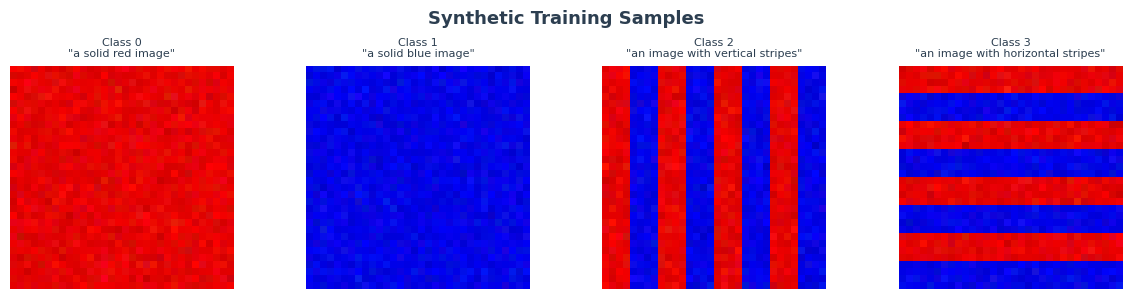

Four visually distinct classes — each has a unique caption.


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle("Synthetic Training Samples", fontsize=13,
             fontweight="bold", color=PAL["dark"])
for cls in range(4):
    img, _, _, label = next(x for x in dataset.data if x[3] == cls)
    axes[cls].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[cls].set_title(f'Class {cls}\n"{CAPTIONS[cls]}"', fontsize=8,
                        color=PAL["dark"])
    axes[cls].axis("off")
plt.tight_layout()
plt.savefig("figures/dataset_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("Four visually distinct classes — each has a unique caption.")


### Instantiate the Small VLM

Small dims for CPU training speed. The two-stage protocol is identical regardless of model size.


In [10]:
VIT_DIM  = 32   # ViT embedding dimension
LANG_DIM = 64   # GPT embedding dimension

vit  = ViTEncoder(img_size=32, patch_size=8, in_ch=3,
                  embed_dim=VIT_DIM, depth=1, n_heads=2)
proj = ProjectionMLP(vision_dim=VIT_DIM, lang_dim=LANG_DIM)
gpt  = GPTDecoder(vocab_size=tokenizer.vocab_size, embed_dim=LANG_DIM,
                  depth=1, n_heads=2, max_seq=MAX_CAP + N_VISUAL + 4)

model = VisionLanguageModel(vit, proj, gpt).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
vit_p = sum(p.numel() for p in model.vit.parameters())
prj_p = sum(p.numel() for p in model.proj.parameters())
gpt_p = sum(p.numel() for p in model.gpt.parameters())
print(f"ViT:        {vit_p:>8,}  ({100*vit_p/total:.1f}%)")
print(f"Projection: {prj_p:>8,}  ({100*prj_p/total:.1f}%)")
print(f"GPT:        {gpt_p:>8,}  ({100*gpt_p/total:.1f}%)")
print(f"Total:      {total:>8,}")


ViT:          19,520  (24.3%)
Projection:    6,272  (7.8%)
GPT:          54,592  (67.9%)
Total:        80,384


## Problem 2 (Solution) — Stage 1: Only the Translator Trains

**The key mechanism:**

```python
model.set_stage1()
# vit.requires_grad_(False)   → no gradients, no weight updates
# gpt.requires_grad_(False)   → same
# proj.requires_grad_(True)   → only projection accumulates gradients
```

The optimizer receives only `proj` parameters — ViT and GPT weights never change.

**How to verify it's working:** Loss should drop — the projection is learning to map patch tokens into a space where GPT's *frozen* language head can predict the correct caption characters.

**Learning rate:** `3e-3` for Stage 1 — the projection starts from random init and needs to move quickly.


In [11]:
def train_epoch(model, loader, optimiser):
    model.train()
    total_loss = 0.0
    for imgs, caps, labels in loader:
        imgs, caps, labels = imgs.to(DEVICE), caps.to(DEVICE), labels.to(DEVICE)
        _, loss = model(imgs, caps, labels=labels)
        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        total_loss += loss.item()
    return total_loss / len(loader)


model.set_stage1()
opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=3e-3)

STAGE1_EPOCHS = 20
stage1_losses = []
print(f"Stage 1: training ProjectionMLP for {STAGE1_EPOCHS} epochs ...")
for ep in range(STAGE1_EPOCHS):
    loss = train_epoch(model, dataloader, opt1)
    stage1_losses.append(loss)
    if (ep + 1) % 5 == 0:
        print(f"  Epoch {ep+1:3d}/{STAGE1_EPOCHS}  loss = {loss:.4f}")
print(f"Stage 1 done. Final loss: {stage1_losses[-1]:.4f}")


Stage 1 active: 6,272 / 80,384 params  (7.8%)


Stage 1: training ProjectionMLP for 20 epochs ...


  Epoch   5/20  loss = 35.8328
  Epoch  10/20  loss = 34.8704


  Epoch  15/20  loss = 33.8581
  Epoch  20/20  loss = 33.1579
Stage 1 done. Final loss: 33.1579


**What we just saw:** Loss dropped — the ProjectionMLP learned to emit vectors that GPT's frozen language head can use to predict caption characters.

The curve typically shows a steep initial drop then a **plateau** — the ceiling of what the projection alone can achieve while GPT is completely frozen. GPT's attention weights were trained on text only; they can leverage visual tokens only in the limited ways already encoded in their frozen weights.

That plateau is the signal to move to Stage 2.


## Problem 3 — Stage 2: Fine-Tune the Conversation (ProjectionMLP + GPT)

The projection is now calibrated. Now we **unfreeze GPT** so it can adapt its attention patterns to the visual prefix.

**Why keep ViT frozen throughout?**
- The ViT encodes general visual knowledge built from massive pretraining
- Our image-caption dataset is tiny by comparison
- Unfreezing ViT would let caption-specific gradients overwrite general visual knowledge — *catastrophic forgetting* of edges, textures, objects

**Why lower learning rate in Stage 2?** (`1e-4` vs `3e-3`)
- GPT weights encode hard-won language priors — only careful, small updates
- Cosine scheduler further decays the LR for graceful convergence


In [12]:
# Save Stage 1 weights before Stage 2 modifies them
stage1_ckpt = copy.deepcopy(model.state_dict())

model.set_stage2()
opt2   = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=20, eta_min=1e-5)

STAGE2_EPOCHS = 20
stage2_losses = []
print(f"Stage 2: training ProjectionMLP + GPT for {STAGE2_EPOCHS} epochs ...")
for ep in range(STAGE2_EPOCHS):
    loss = train_epoch(model, dataloader, opt2)
    sched2.step()
    stage2_losses.append(loss)
    if (ep + 1) % 5 == 0:
        lr_now = opt2.param_groups[0]["lr"]
        print(f"  Epoch {ep+1:3d}/{STAGE2_EPOCHS}  loss = {loss:.4f}  lr = {lr_now:.2e}")
print(f"Stage 2 done. Final loss: {stage2_losses[-1]:.4f}")


Stage 2 active: 60,864 / 80,384 params  (75.7%)
Stage 2: training ProjectionMLP + GPT for 20 epochs ...


  Epoch   5/20  loss = 32.4052  lr = 8.68e-05


  Epoch  10/20  loss = 31.7253  lr = 5.50e-05


  Epoch  15/20  loss = 31.3149  lr = 2.32e-05


  Epoch  20/20  loss = 31.1475  lr = 1.00e-05
Stage 2 done. Final loss: 31.1475


**What we just saw:** Loss continued dropping *below* the Stage 1 plateau. GPT is now adapting its attention to pay attention to the right visual tokens when predicting each caption character. The cosine LR ensures updates become smaller and more conservative as training progresses.


### Visualising the Training Curves

Both stages on a single axis. The vertical dashed line marks the Stage 1 → Stage 2 transition.


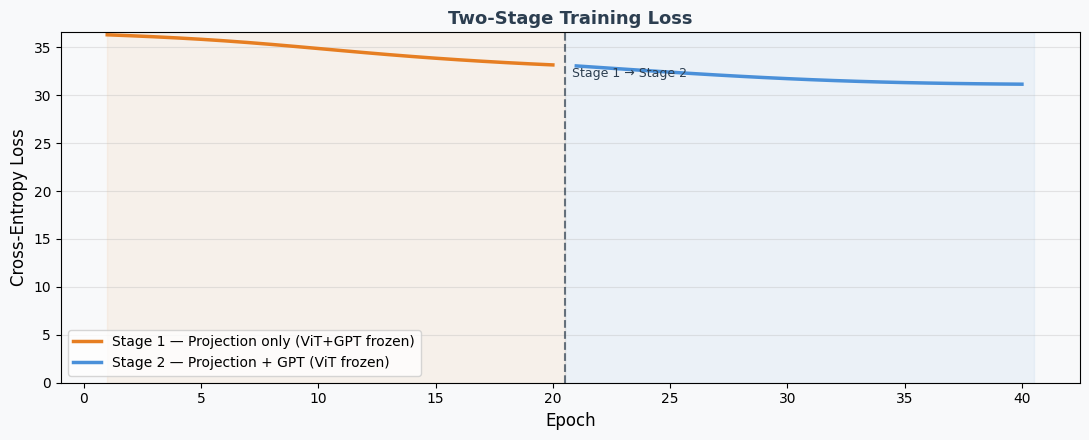

Stage 1 final loss : 33.1579
Stage 2 final loss : 31.1475
Improvement S1→S2  : 2.0104


In [13]:
def plot_stage_losses(s1_losses, s2_losses):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.patch.set_facecolor(PAL["bg"])
    ax.set_facecolor(PAL["bg"])

    e1 = list(range(1, len(s1_losses) + 1))
    e2 = list(range(len(s1_losses) + 1, len(s1_losses) + len(s2_losses) + 1))

    ax.plot(e1, s1_losses, color=PAL["orange"], lw=2.5,
            label="Stage 1 — Projection only (ViT+GPT frozen)")
    ax.plot(e2, s2_losses, color=PAL["blue"],   lw=2.5,
            label="Stage 2 — Projection + GPT (ViT frozen)")

    boundary = len(s1_losses) + 0.5
    ax.axvline(boundary, color=PAL["dark"], lw=1.5, ls="--", alpha=0.7)
    ax.text(boundary + 0.3, max(s1_losses) * 0.88,
            "Stage 1 → Stage 2", fontsize=9, color=PAL["dark"])
    ax.axvspan(1, boundary,             alpha=0.07, color=PAL["orange"])
    ax.axvspan(boundary, e2[-1] + 0.5,  alpha=0.07, color=PAL["blue"])

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
    ax.set_title("Two-Stage Training Loss", fontsize=13,
                 fontweight="bold", color=PAL["dark"])
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/stage_losses.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Stage 1 final loss : {s1_losses[-1]:.4f}")
    print(f"Stage 2 final loss : {s2_losses[-1]:.4f}")
    print(f"Improvement S1→S2  : {s1_losses[-1] - s2_losses[-1]:.4f}")

plot_stage_losses(stage1_losses, stage2_losses)


### Ablation: Does Stage 1 Actually Help?

Three conditions — same total training budget (40 epochs each), same architecture:

| Condition | What trains | Epochs |
|-----------|-------------|--------|
| No training | nothing | — |
| Stage 1 only | Projection only | 40 |
| **Stage 1+2 (ours)** | Projection → Projection+GPT | 20+20 |

Expected: Stage 1+2 reaches the lowest loss. Stage-1-only plateaus. This quantifies the value of each stage.


In [14]:
# ── Condition A: Stage 1 only (40 epochs projection-only) ─────────────────────
torch.manual_seed(77)
vit_a   = ViTEncoder(img_size=32, patch_size=8, in_ch=3,
                     embed_dim=VIT_DIM, depth=1, n_heads=2)
proj_a  = ProjectionMLP(VIT_DIM, LANG_DIM)
gpt_a   = GPTDecoder(tokenizer.vocab_size, LANG_DIM, depth=1, n_heads=2,
                     max_seq=MAX_CAP + N_VISUAL + 4)
model_a = VisionLanguageModel(vit_a, proj_a, gpt_a).to(DEVICE)
model_a.set_stage1()
opt_a   = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_a.parameters()), lr=3e-3)
abl_s1only = []
print("Ablation A: Stage 1 only (40 epochs) ...")
for ep in range(40):
    abl_s1only.append(train_epoch(model_a, dataloader, opt_a))
print(f"  Stage-1-only final loss: {abl_s1only[-1]:.4f}")

# ── Condition B: No training baseline ──────────────────────────────────────────
torch.manual_seed(55)
vit_b   = ViTEncoder(img_size=32, patch_size=8, in_ch=3,
                     embed_dim=VIT_DIM, depth=1, n_heads=2)
proj_b  = ProjectionMLP(VIT_DIM, LANG_DIM)
gpt_b   = GPTDecoder(tokenizer.vocab_size, LANG_DIM, depth=1, n_heads=2,
                     max_seq=MAX_CAP + N_VISUAL + 4)
model_b = VisionLanguageModel(vit_b, proj_b, gpt_b).to(DEVICE)
model_b.eval()
with torch.no_grad():
    no_train_loss = sum(
        model_b(im.to(DEVICE), ca.to(DEVICE), la.to(DEVICE))[1].item()
        for im, ca, la in dataloader
    ) / len(dataloader)
print(f"  No-training baseline loss: {no_train_loss:.4f}")


Stage 1 active: 6,272 / 80,384 params  (7.8%)
Ablation A: Stage 1 only (40 epochs) ...


  Stage-1-only final loss: 33.2703
  No-training baseline loss: 36.2708


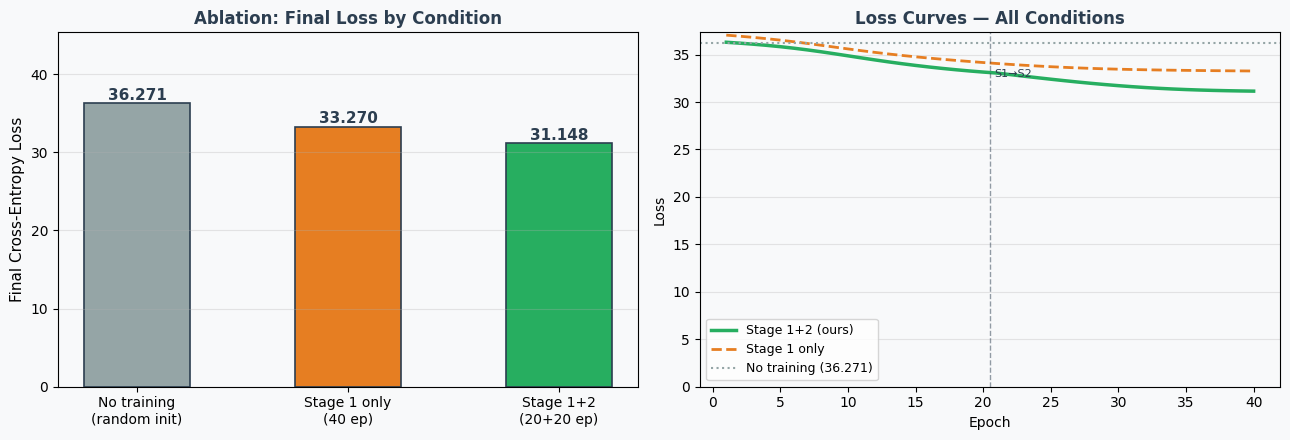

No-train → S1-only improvement  : 3.0004
S1-only  → S1+S2 improvement    : 2.1228
Total improvement               : 5.1232


In [15]:
def plot_ablation(no_train, s1only, two_s1, two_s2):
    final_nt  = no_train
    final_s1  = s1only[-1]
    final_s12 = two_s2[-1]
    full      = two_s1 + two_s2

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor(PAL["bg"])

    # Left: bar chart of final losses
    ax = axes[0]; ax.set_facecolor(PAL["bg"])
    conds  = ["No training\n(random init)", "Stage 1 only\n(40 ep)", "Stage 1+2\n(20+20 ep)"]
    values = [final_nt, final_s1, final_s12]
    colors = [PAL["grey"], PAL["orange"], PAL["green"]]
    bars   = ax.bar(conds, values, color=colors, edgecolor=PAL["dark"],
                    linewidth=1.2, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=PAL["dark"])
    ax.set_ylabel("Final Cross-Entropy Loss", fontsize=11)
    ax.set_title("Ablation: Final Loss by Condition", fontsize=12,
                 fontweight="bold", color=PAL["dark"])
    ax.set_ylim(0, max(values) * 1.25)
    ax.grid(axis="y", alpha=0.3)

    # Right: loss curves
    ax2 = axes[1]; ax2.set_facecolor(PAL["bg"])
    ax2.plot(range(1, len(full)+1), full,
             color=PAL["green"], lw=2.5, label="Stage 1+2 (ours)")
    ax2.plot(range(1, len(s1only)+1), s1only,
             color=PAL["orange"], lw=2, ls="--", label="Stage 1 only")
    ax2.axhline(final_nt, color=PAL["grey"], lw=1.5, ls=":",
                label=f"No training ({final_nt:.3f})")
    boundary = len(two_s1) + 0.5
    ax2.axvline(boundary, color=PAL["dark"], lw=1, ls="--", alpha=0.5)
    ax2.text(boundary + 0.3, max(full) * 0.9, "S1→S2",
             fontsize=8, color=PAL["dark"])
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title("Loss Curves — All Conditions", fontsize=12,
                  fontweight="bold", color=PAL["dark"])
    ax2.legend(fontsize=9); ax2.set_ylim(bottom=0); ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("figures/ablation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"No-train → S1-only improvement  : {final_nt - final_s1:.4f}")
    print(f"S1-only  → S1+S2 improvement    : {final_s1 - final_s12:.4f}")
    print(f"Total improvement               : {final_nt - final_s12:.4f}")

plot_ablation(no_train_loss, abl_s1only, stage1_losses, stage2_losses)


**Reading the ablation results:**

- **No training → Stage 1 only**: Large drop — the projection learning to "translate" visual features is responsible for most of the alignment gain.
- **Stage 1 only → Stage 1+Stage 2**: Additional drop — GPT co-adapting its attention to the aligned visual prefix provides meaningful extra capacity.
- **Stage 1 plateau**: The Stage-1-only curve flattens — the projection alone cannot make GPT attend optimally to visual information without GPT adapting.

The two-stage protocol concentrates most learning in Stage 1 (cheapest — fewest trainable params) and uses Stage 2 as a targeted refinement.


### Loss Masking Deep-Dive

In real instruction-tuning datasets, each sample looks like:

```
[VISUAL TOKENS]  <SOS>  describe the image:  The object is red.  <EOS>
```

We only want gradients from the **answer** tokens:

```python
labels = input_ids.clone()
labels[:n_instruction] = -100    # mask instruction prefix
# F.cross_entropy(ignore_index=-100) → skips those positions automatically
```

Our `ImageCaptionDataset` already masks the `<SOS>` token. Let's visualise the mask for one sample.


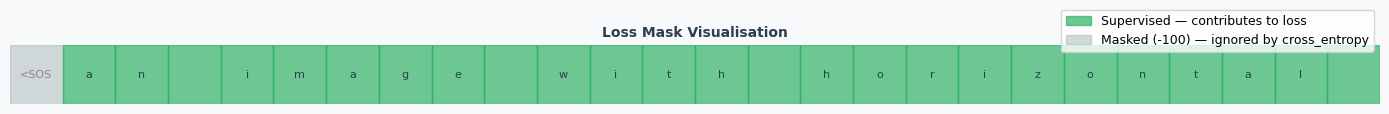

Masked: 1  |  Supervised: 25


In [16]:
sample_ids    = caps[0].tolist()
sample_labels = lbls[0].tolist()

fig, ax = plt.subplots(figsize=(14, 1.8))
fig.patch.set_facecolor(PAL["bg"])
ax.set_facecolor(PAL["bg"])

for i, (tid, lid) in enumerate(zip(sample_ids, sample_labels)):
    tok   = tokenizer.itos.get(tid, "?")
    color = PAL["green"] + "AA" if lid != -100 else PAL["grey"] + "66"
    ax.add_patch(plt.Rectangle([i, 0], 1, 1, color=color))
    ax.text(i + 0.5, 0.5, tok if len(tok) == 1 else tok[:4],
            ha="center", va="center", fontsize=8,
            color=PAL["dark"] if lid != -100 else "#888")

ax.set_xlim(0, len(sample_ids)); ax.set_ylim(0, 1); ax.axis("off")
green_p = mpatches.Patch(color=PAL["green"] + "AA",
                          label="Supervised — contributes to loss")
grey_p  = mpatches.Patch(color=PAL["grey"]  + "66",
                          label="Masked (-100) — ignored by cross_entropy")
ax.legend(handles=[green_p, grey_p], loc="upper right",
          bbox_to_anchor=(1, 1.7), fontsize=9)
ax.set_title("Loss Mask Visualisation", fontsize=10,
             fontweight="bold", color=PAL["dark"])
plt.tight_layout()
plt.savefig("figures/loss_mask.png", dpi=120, bbox_inches="tight")
plt.show()
n_masked = sum(1 for l in sample_labels if l == -100)
n_super  = sum(1 for l in sample_labels if l != -100)
print(f"Masked: {n_masked}  |  Supervised: {n_super}")


## Chapter Summary

We solved the three problems of connecting a pretrained ViT to a pretrained GPT:

| Problem | Solution | Key Code |
|---------|----------|----------|
| Joint training destroys pretrained features | Two-stage protocol | Two separate training loops |
| Projection needs to translate visual features | Stage 1: freeze ViT+GPT, train proj only | `requires_grad_(False)` |
| GPT needs to adapt to visual input safely | Stage 2: unfreeze GPT, cosine LR | `CosineAnnealingLR`, low lr |

**Key insights:**
- ViT stays frozen in **both** stages — general visual knowledge is too valuable to overwrite
- `requires_grad_(False)` is all that freezes a component — PyTorch skips gradient computation automatically
- Loss masking (`labels = -100`) is how instruction-following is implemented — only answer tokens are supervised
- Stage 1 trains only ~5% of parameters but delivers most of the alignment gain

---

**Chapter 5 preview — Inference:** Chapter 5 covers autoregressive generation: greedy, top-k, nucleus sampling, beam search, and evaluation metrics (BLEU, perplexity).
